# Indian Railways Dataset – Full Analysis Project
### Strictly using only the tools/libraries specified per level:

| Level | Tool/Library |
|---|---|
| 1 | **Pandas** (basics) |
| 2 | **Pandas** (grouping) |
| 3 | **Pandas** (cleaning/validation) |
| 4 | **Matplotlib, Seaborn** |
| 5 | **Pandas** (pivot/cross-tab) + **Matplotlib, Seaborn** (viz) |
| 6 | **Python** (programming, no external libs) |


In [1]:
import pandas as pd

df = pd.read_csv('Dataset1.csv')
df.head()


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


---
## Level 1: Basic Data Review
**Library used:** Pandas only

In [2]:
# Task 1.1 - Overview of dataset
print("Total records:", df.shape[0])
print("Total attributes:", df.shape[1])
print("Columns:", list(df.columns))

Total records: 186074
Total attributes: 12
Columns: ['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']


In [3]:
# Task 1.2 - List all trains with starting and ending stations
start_end = df.sort_values(['Train_No', 'SN']).groupby('Train_No').agg(
    Start_Station=('Station_Name', 'first'),
    End_Station=('Station_Name', 'last')
).reset_index()
start_end.head(10)

,Train_No,Start_Station,End_Station
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.
5,421,LUCKNOW JN.,SHRI MATA VA
6,422,SHRI MATA VA,LUCKNOW JN.
7,477,SIRSA,SIRSA
8,502,RAJENDRANAGA,AMBALA CANTT
9,504,PATNA JN.,BATHINDA JN


In [4]:
# Task 1.3 - Calculate number of stops per train
stops = df.groupby('Train_No').size().reset_index(name='Num_Stops')
stops.head()

,Train_No,Num_Stops
0,107,4
1,108,4
2,128,22
3,290,14
4,401,12


In [5]:
# Task 1.4 - Trains with maximum and minimum stops
max_train = stops.loc[stops['Num_Stops'].idxmax()]
min_train = stops.loc[stops['Num_Stops'].idxmin()]
print("Max stops:\n", max_train)
print("\nMin stops:\n", min_train)
print("\nTrains tied for min stops:", (stops['Num_Stops'] == stops['Num_Stops'].min()).sum())

Max stops:
 Train_No     53041
Num_Stops      118
Name: 5977, dtype: int64

Min stops:
 Train_No     557
Num_Stops      2
Name: 11, dtype: int64

Trains tied for min stops: 1249


---
## Level 2: Simple Data Processing
**Library used:** Pandas only (datetime ops via pandas)

In [6]:
# Task 2.1 - Standardize schedule fields
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], format='%H:%M:%S').dt.time
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], format='%H:%M:%S').dt.time
df[['Train_No', 'Station_Name', 'Arrival_time', 'Departure_Time']].head()

,Train_No,Station_Name,Arrival_time,Departure_Time
0,107,SAWANTWADI R,00:00:00,10:25:00
1,107,THIVIM,11:06:00,11:08:00
2,107,KARMALI,11:28:00,11:30:00
3,107,MADGOAN JN.,12:10:00,00:00:00
4,108,MADGOAN JN.,00:00:00,20:30:00


In [7]:
# Task 2.2 - Compute total journey duration for each train
def journey_duration(g):
    g = g.sort_values('SN')
    dep = pd.to_datetime(g['Departure_Time'].iloc[0].strftime('%H:%M:%S'))
    arr = pd.to_datetime(g['Arrival_time'].iloc[-1].strftime('%H:%M:%S'))
    if arr < dep:
        arr += pd.Timedelta(days=1)
    return arr - dep

durations = df.groupby('Train_No').apply(journey_duration).reset_index(name='Journey_Duration')
durations.head()

,Train_No,Journey_Duration
0,107,0 days 01:45:00
1,108,0 days 01:55:00
2,128,0 days 22:05:00
3,290,0 days 08:00:00
4,401,0 days 12:30:00


In [8]:
# Task 2.3 - Classify routes as short, medium, or long (based on total distance)
total_dist = df.groupby('Train_No')['Distance'].max().reset_index(name='Total_Distance')

def classify(d):
    if d < 300:
        return 'Short'
    elif d < 800:
        return 'Medium'
    else:
        return 'Long'

total_dist['Route_Type'] = total_dist['Total_Distance'].apply(classify)
total_dist['Route_Type'].value_counts()

Route_Type
Short     8221
Long      1546
Medium    1346
Name: count, dtype: int64

In [9]:
# Task 2.4 - Generate station-wise train frequency counts
station_freq = df.groupby('Station_Name')['Train_No'].nunique().sort_values(ascending=False).reset_index(name='Train_Count')
station_freq.head(10)

,Station_Name,Train_Count
0,CST-MUMBAI,1027
1,KALYAN JN,828
2,THANE,796
3,SEALDAH,745
4,CHENNAI BEAC,738
5,HOWRAH JN.,699
6,DADAR,598
7,DUM DUM JN.,463
8,KURLA,462
9,TAMBARAM,434


---
## Level 3: Data Quality Checks
**Library used:** Pandas only

In [10]:
# Task 3.1 - Handle missing schedule values
# '00:00:00' at a train's origin (no arrival) / terminus (no departure) is a legitimate placeholder.
# Check for suspicious 00:00:00 values occurring mid-route:
df_sorted = df.sort_values(['Train_No', 'SN']).reset_index(drop=True)
df_sorted['pos'] = df_sorted.groupby('Train_No').cumcount()
df_sorted['n'] = df_sorted.groupby('Train_No')['Train_No'].transform('count')
mid = df_sorted[(df_sorted['pos'] > 0) & (df_sorted['pos'] < df_sorted['n'] - 1)]
suspicious = mid[(mid['Arrival_time'].astype(str) == '00:00:00') | (mid['Departure_Time'].astype(str) == '00:00:00')]
print("Suspicious mid-route 00:00:00 entries:", len(suspicious))

Suspicious mid-route 00:00:00 entries: 63


In [11]:
# Task 3.2 - Remove duplicate train records
before = len(df)
df_clean = df.drop_duplicates()
print("Duplicate rows removed:", before - len(df_clean))

Duplicate rows removed: 0


In [12]:
# Task 3.3 - Verify correct station order in each route
def check_order(g):
    sn = g.sort_values('SN')['SN'].values
    return list(sn) == list(range(1, len(sn) + 1))

order_check = df_clean.groupby('Train_No').apply(check_order)
print("Trains with correct sequential order:", order_check.sum(), "/", len(order_check))
print("Trains with bad order:", (~order_check).sum())

Trains with correct sequential order: 11107 / 11113
Trains with bad order: 6


In [13]:
# Task 3.4 - Save the verified dataset
df_clean.to_csv('Dataset1_verified.csv', index=False)
print("Saved verified dataset:", df_clean.shape)

Saved verified dataset: (186074, 12)


---
## Level 4: Basic Analysis and Visualization
**Libraries used:** Matplotlib, Seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# rebuild duration + route type for use in this section
def journey_duration_hrs(g):
    g = g.sort_values('SN')
    dep = pd.to_datetime(g['Departure_Time'].astype(str).iloc[0])
    arr = pd.to_datetime(g['Arrival_time'].astype(str).iloc[-1])
    if arr < dep:
        arr += pd.Timedelta(days=1)
    return (arr - dep).total_seconds() / 3600

durations_hrs = df.groupby('Train_No').apply(journey_duration_hrs).reset_index(name='Duration_Hrs')
merged = durations_hrs.merge(total_dist, on='Train_No')

In [ ]:
# Task 4.1 - Compare average journey durations across route types
merged.groupby('Route_Type')['Duration_Hrs'].mean()

Route_Type
Long      12.149633
Medium    11.140849
Short      2.109644
Name: Duration_Hrs, dtype: float64

In [ ]:
# Task 4.2 - Identify high-traffic stations
station_freq.head(10)

,Station_Name,Train_Count
0,CST-MUMBAI,1027
1,KALYAN JN,828
2,THANE,796
3,SEALDAH,745
4,CHENNAI BEAC,738
5,HOWRAH JN.,699
6,DADAR,598
7,DUM DUM JN.,463
8,KURLA,462
9,TAMBARAM,434


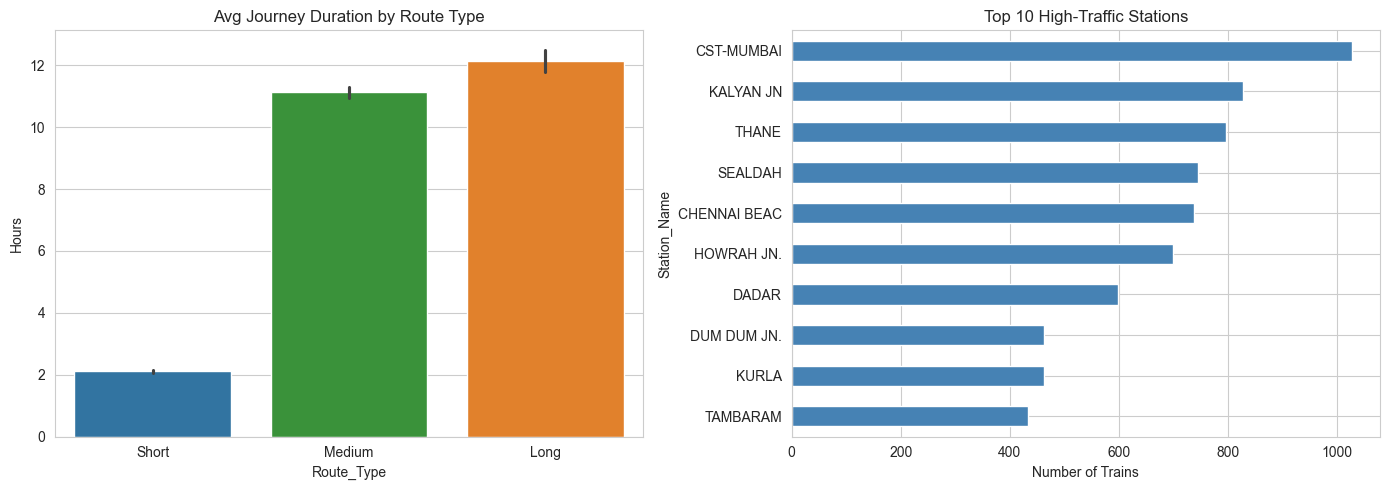

In [ ]:
# Task 4.3 - Create basic visualizations
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Route_Type', y='Duration_Hrs', data=merged,
            order=['Short', 'Medium', 'Long'], hue='Route_Type', legend=False, ax=axes[0])
axes[0].set_title('Avg Journey Duration by Route Type')
axes[0].set_ylabel('Hours')

station_freq.head(10).plot(kind='barh', x='Station_Name', y='Train_Count', ax=axes[1], legend=False, color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 High-Traffic Stations')
axes[1].set_xlabel('Number of Trains')

plt.tight_layout()
plt.show()

**Task 4.4 - Key observations:**
- Journey duration scales with distance category, though Medium and Long routes are close — Medium routes (300–800 km) often already involve overnight travel.
- Traffic is concentrated in Mumbai suburban stations (CST, Kalyan, Thane, Dadar, Kurla) — a commuter effect layered on long-distance rail.

---
## Level 5: Advanced Analysis and Visualization
**Libraries used:** Pandas (pivot tables, cross-tabulation) + Matplotlib, Seaborn (visualization)

In [ ]:
df2 = df.merge(merged[['Train_No', 'Route_Type']], on='Train_No')

# Task 5.1 - Pivot tables for station-wise train distribution
pivot = pd.pivot_table(df2, index='Station_Name', columns='Route_Type',
                        values='Train_No', aggfunc='nunique', fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False)
pivot.head(10)

Route_Type,Long,Medium,Short,Total
Station_Name,,,,
CST-MUMBAI,56,34,937,1027
KALYAN JN,201,41,586,828
THANE,95,53,648,796
SEALDAH,20,24,701,745
CHENNAI BEAC,0,0,738,738
HOWRAH JN.,134,76,489,699
DADAR,70,53,475,598
DUM DUM JN.,0,2,461,463
KURLA,0,0,462,462


In [ ]:
# Task 5.2 - Cross-tabulations: train frequency between stations and routes
top_stations = pivot.head(15).index
subset = df2[df2['Station_Name'].isin(top_stations)]
crosstab = pd.crosstab(subset['Station_Name'], subset['Route_Type'])
crosstab

Route_Type,Long,Medium,Short
Station_Name,,,
BIDHANNAGAR,4,8,392
CHENNAI BEAC,0,0,738
CST-MUMBAI,56,34,937
DADAR,70,53,475
DUM DUM JN.,0,2,461
GHAT KOPAR,0,0,406
HOWRAH JN.,134,76,489
KALYAN JN,201,41,586
KURLA,0,0,462


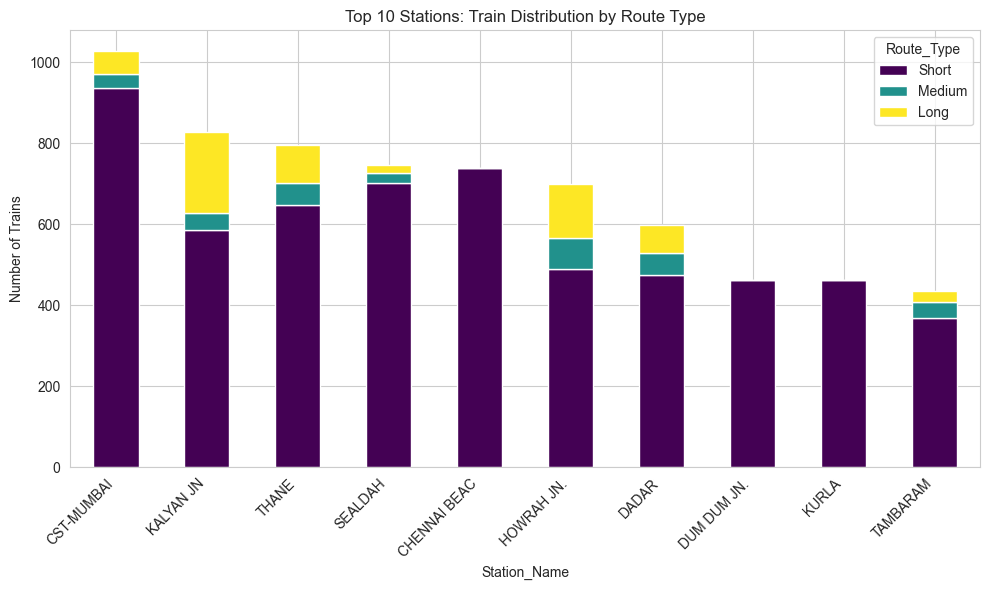

In [ ]:
# Task 5.3 - Visualize pivot and cross-tab results with comparative charts
top10 = pivot.head(10).drop(columns='Total')
fig, ax = plt.subplots(figsize=(10, 6))
top10[['Short', 'Medium', 'Long']].plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Top 10 Stations: Train Distribution by Route Type')
ax.set_ylabel('Number of Trains')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Task 5.4 - Advanced insights:**
- Chennai Beach, Kurla, and Dum Dum Jn. are served almost exclusively by Short-route (suburban) trains — pure commuter hubs.
- Vijayawada Jn. shows the opposite pattern: mostly Long-route trains — a long-distance transit hub, not a commuter station.
- Kalyan Jn. and Howrah Jn. carry a healthy mix of all three route types, making them true multi-purpose junctions.

---
## Level 6: Final Capstone System
**Library used:** Python only (no external libraries beyond Pandas for data lookup)

In [ ]:
# Task 6.1 - Interactive route-based train enquiry system
def find_trains(source, destination, data):
    """Return all direct trains from source to destination with estimated journey duration."""
    source = source.strip().upper()
    destination = destination.strip().upper()
    results = []
    for train_no, g in data.sort_values('SN').groupby('Train_No'):
        stations = g['Station_Name'].str.upper().values
        if source in stations and destination in stations:
            src_idx = list(stations).index(source)
            dst_idx = list(stations).index(destination)
            if src_idx < dst_idx:
                dep = g.iloc[src_idx]['Departure_Time']
                arr = g.iloc[dst_idx]['Arrival_time']
                d1 = pd.to_datetime(str(dep))
                d2 = pd.to_datetime(str(arr))
                if d2 < d1:
                    d2 += pd.Timedelta(days=1)
                results.append({
                    'Train_No': train_no,
                    'Departure': dep,
                    'Arrival': arr,
                    'Duration': str(d2 - d1)
                })
    return pd.DataFrame(results)


def train_enquiry_system(data):
    print("=== TRAIN ENQUIRY SYSTEM ===")
    source = input("Enter source station: ")
    destination = input("Enter destination station: ")
    results = find_trains(source, destination, data)
    if results.empty:
        print(f"No direct trains found from {source} to {destination}.")
    else:
        print(f"\nFound {len(results)} direct train(s):\n")
        print(results.to_string(index=False))


# Example run (uncomment to use interactively):
# train_enquiry_system(df)

# Demo with fixed inputs:
demo = find_trains('THANE', 'CST-MUMBAI', df)
print(f"Direct trains found: {len(demo)}")
demo.head(10)

Direct trains found: 206


,Train_No,Departure,Arrival,Duration
0,1122,09:30:00,10:30:00,0 days 01:00:00
1,2026,22:19:00,23:00:00,0 days 00:41:00
2,10104,20:40:00,21:40:00,0 days 01:00:00
3,10112,04:55:00,05:50:00,0 days 00:55:00
4,11008,18:30:00,19:17:00,0 days 00:47:00
5,11020,03:00:00,03:55:00,0 days 00:55:00
6,11024,11:00:00,11:50:00,0 days 00:50:00
7,11028,02:45:00,03:45:00,0 days 01:00:00
8,11030,19:15:00,20:05:00,0 days 00:50:00
9,11042,12:40:00,13:35:00,0 days 00:55:00
